# Model Evaluation and Model Selection

## Introduction

Developing a machine learning model involves more than achieving good performance on training data. A model must be able to generalize to unseen examples and make reliable predictions in real-world scenarios.

A common mistake is to evaluate a model solely based on its training performance. While a model may achieve very low training error, this does not necessarily indicate that it will perform well on new data. To address this challenge, machine learning practitioners use separate datasets for training, validation, and testing.

In this notebook, we will explore how machine learning models are evaluated and selected. Using a synthetic regression dataset, we will investigate how model complexity affects performance and how cross-validation can be used to choose an appropriate model.

## Objective

The goal of this notebook is to understand how machine learning models should be evaluated and selected.

Specifically, we aim to:

- Understand the roles of training, cross-validation, and test datasets.
- Learn how model performance is estimated on unseen data.
- Investigate the relationship between model complexity and generalization.
- Demonstrate how cross-validation supports model selection.
- Develop intuition for making evidence-based decisions during machine learning development.

## Background Theory

The primary objective of machine learning is not simply to fit the available data, but to generalize effectively to unseen examples. Proper model evaluation helps estimate how well a model is expected to perform when deployed in real-world environments.

To accomplish this, machine learning practitioners typically divide data into separate subsets for training, validation, and testing. These datasets serve different purposes throughout the development process and help reduce the risk of overfitting.

### Why Model Evaluation Matters

A model that performs exceptionally well on training data may still perform poorly on new data. This occurs when the model memorizes patterns specific to the training dataset instead of learning relationships that generalize.

Without proper evaluation procedures, it becomes difficult to determine whether improvements in performance are genuine or simply the result of overfitting.

### Train, Cross-Validation, and Test Sets

A common approach in machine learning is to split data into three subsets:

**Training Set**
- Used to train the model.
- The model learns patterns and parameters from this data.

**Cross-Validation Set**
- Used during development to compare candidate models.
- Helps estimate generalization performance.

**Test Set**
- Used only after model selection is complete.
- Provides an unbiased estimate of final model performance.

### Model Selection

Different models often have different levels of complexity. Some models may be too simple to capture important patterns, while others may be so complex that they begin fitting noise present in the training data.

Cross-validation performance provides a systematic way to compare candidate models and select the one most likely to generalize well to unseen data.

## Experimental Question

How can training, cross-validation, and test datasets be used to reliably estimate model performance and select an appropriate machine learning model?

## Dataset Generation

A synthetic regression dataset is used in this notebook to provide a controlled environment for studying model evaluation and selection. Unlike real-world datasets, synthetic data allows us to clearly visualize the relationship between model complexity and generalization performance.

The dataset is generated from a sinusoidal function with added Gaussian noise. This creates a non-linear relationship that can be approximated with polynomial regression models of varying complexity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

In [2]:
np.random.seed(42)

In [3]:
#Generate targets
x = np.linspace(-3, 3, 100)

#Generate targets
y = np.sin(x) + np.random.normal(0, 0.2, size=x.shape)

#Reshape for sktlearn
X = x.reshape(-1, 1)

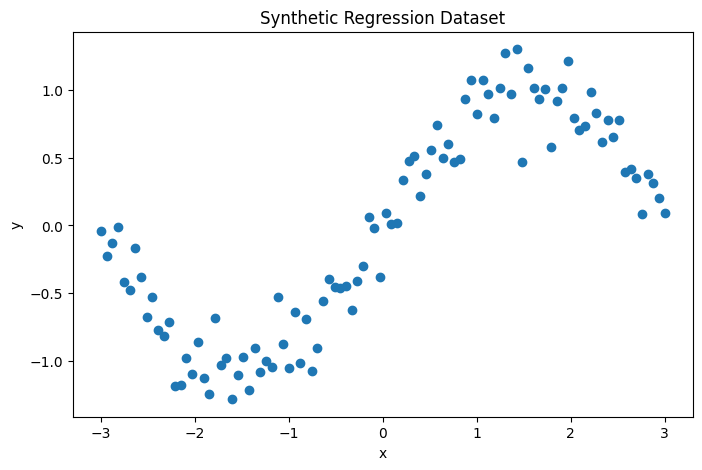

In [4]:
#Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Regression Dataset")
plt.show()


In [5]:
#Split the data into test, cross validation and training splits

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

X_cv, X_test, y_cv, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [6]:
print("Training:", X_train.shape[0])
print("CV:", X_cv.shape[0])
print("Test:", X_test.shape[0])

Training: 60
CV: 20
Test: 20


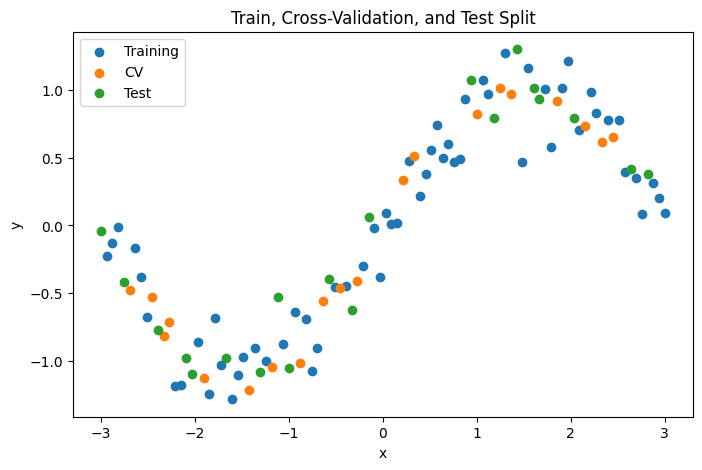

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training")
plt.scatter(X_cv, y_cv, label="CV")
plt.scatter(X_test, y_test, label="Test")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train, Cross-Validation, and Test Split")
plt.legend()

plt.show()

## Experimental Setup

To investigate the relationship between model complexity and generalization performance, polynomial regression models of varying degrees will be trained and evaluated.

The following polynomial degrees will be considered:

- Degree 1
- Degree 3
- Degree 5
- Degree 10

For each model, training, cross-validation, and test Mean Squared Error (MSE) will be computed.

Cross-validation performance will be used to compare candidate models and select the model that is expected to generalize best to unseen data.

In [8]:
degrees = [1, 3, 5, 10]

train_errors = []
cv_errors = []
test_errors = []

In [9]:
for degree in degrees:

    # Create polynomial features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    # Transform datasets
    X_train_poly = poly.fit_transform(X_train)
    X_cv_poly = poly.transform(X_cv)
    X_test_poly = poly.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    train_pred = model.predict(X_train_poly)
    cv_pred = model.predict(X_cv_poly)
    test_pred = model.predict(X_test_poly)

    # Compute errors
    train_mse = mean_squared_error(y_train, train_pred)
    cv_mse = mean_squared_error(y_cv, cv_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_errors.append(train_mse)
    cv_errors.append(cv_mse)
    test_errors.append(test_mse)

In [10]:
for degree, train, cv, test in zip(
    degrees,
    train_errors,
    cv_errors,
    test_errors
):
    print(
        f"Degree {degree}: "
        f"Train={train:.4f}, "
        f"CV={cv:.4f}, "
        f"Test={test:.4f}"
    )

Degree 1: Train=0.2463, CV=0.1833, Test=0.2648
Degree 3: Train=0.0386, CV=0.0187, Test=0.0360
Degree 5: Train=0.0365, CV=0.0118, Test=0.0340
Degree 10: Train=0.0314, CV=0.0240, Test=0.0528


In [11]:
results = pd.DataFrame({
    "Degree": degrees,
    "Train MSE": train_errors,
    "CV MSE": cv_errors,
    "Test MSE": test_errors
})

results

,Degree,Train MSE,CV MSE,Test MSE
0,1,0.246264,0.183344,0.264840
1,3,0.038550,0.018725,0.036044
2,5,0.036483,0.011821,0.033952
3,10,0.031402,0.023992,0.052757


## Visualizing Model Complexity

While training, cross-validation, and test errors provide quantitative evidence of model performance, visualizing the fitted models offers additional intuition.

The plots below compare polynomial regression models of varying complexity. By examining how each model fits the data, we can better understand the concepts of underfitting and overfitting.

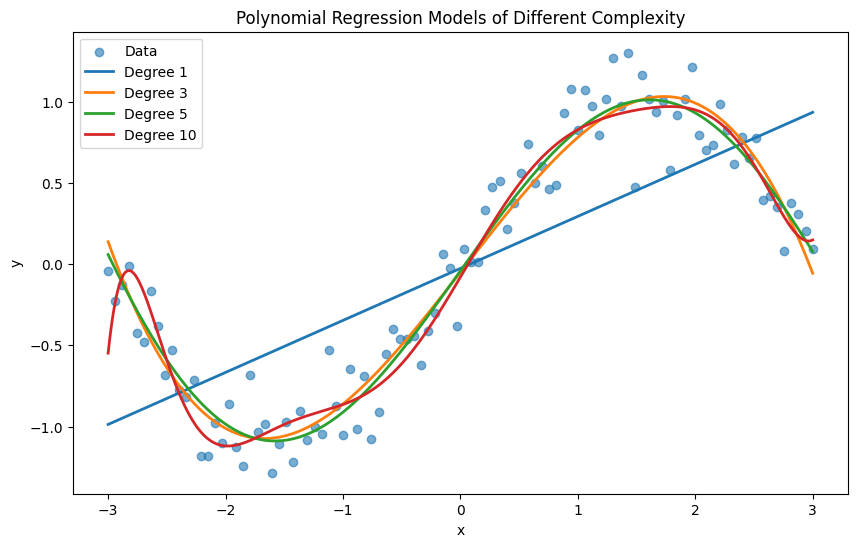

In [12]:
degrees = [1, 3, 5, 10]

x_plot = np.linspace(-3, 3, 500).reshape(-1, 1)

plt.figure(figsize=(10, 6))

plt.scatter(X, y, alpha=0.6, label="Data")

for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    x_plot_poly = poly.transform(x_plot)
    y_plot = model.predict(x_plot_poly)

    plt.plot(
        x_plot,
        y_plot,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression Models of Different Complexity")
plt.legend()
plt.show()

## Results

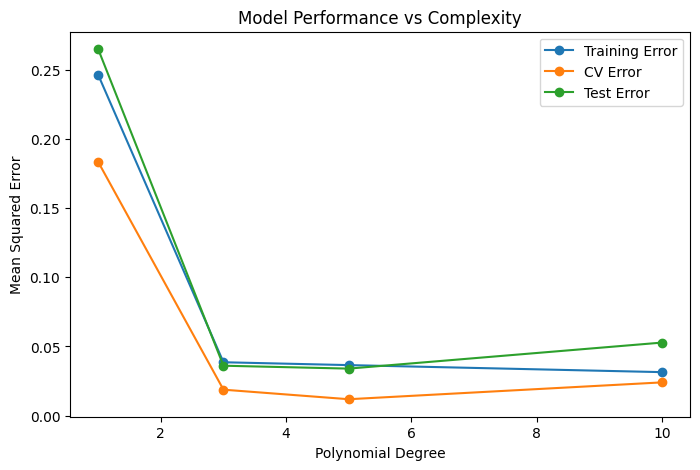

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(degrees, train_errors, marker="o", label="Training Error")
plt.plot(degrees, cv_errors, marker="o", label="CV Error")
plt.plot(degrees, test_errors, marker="o", label="Test Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Performance vs Complexity")
plt.legend()

plt.show()

## Analysis

The degree 1 model produced high training, cross-validation, and test errors, indicating that it was unable to capture the underlying non-linear relationship in the data. This behavior is characteristic of underfitting.

Increasing the polynomial degree significantly improved performance. The degree 3 and degree 5 models achieved substantially lower errors across all datasets, suggesting that they captured the underlying pattern more effectively.

Among the evaluated models, the degree 5 model achieved the lowest cross-validation error and the lowest test error. This indicates that it provided the best balance between model complexity and generalization performance.

Although the degree 10 model achieved the lowest training error, its cross-validation and test errors increased. This suggests that the model began fitting noise present in the training data, resulting in reduced generalization performance. This behavior is consistent with overfitting.

These results demonstrate the importance of cross-validation during model selection. While training error alone would favor the degree 10 model, cross-validation correctly identified the degree 5 model as the better choice for unseen data.

## Conclusion

This notebook explored how machine learning models can be evaluated and selected using training, cross-validation, and test datasets.

Using a synthetic regression dataset, polynomial regression models of varying complexity were trained and compared. The results demonstrated that model complexity has a significant impact on generalization performance.

The degree 1 model underfit the data, while the degree 10 model showed signs of overfitting. The degree 5 model achieved the best balance between fitting the underlying pattern and generalizing to unseen data.

Most importantly, the experiment highlighted the value of cross-validation. Although the degree 10 model achieved the lowest training error, cross-validation correctly identified that the degree 5 model generalized better. This illustrates why model selection should be based on validation performance rather than training performance alone.

## Key Takeaways

- Training error alone is not sufficient for model evaluation.
- Cross-validation provides a more reliable estimate of generalization performance.
- Increasing model complexity can reduce bias but may increase variance.
- Model selection should be guided by validation performance.
- Test data should remain untouched until final evaluation.